# CIMBA — pipeline tour for code review

This notebook walks through the five processing stages of CIMBA (S1 to S5)
on a small snapshot of real data from the Newcastle Helix Spark building.

It reads files directly from this repository, so you do **not** need to
install MongoDB to run it. Open it, run the cells from top to bottom, and
read the comments. If you want to make changes, please use a pull request
or a GitHub issue with a code reference.

The five stages are:

1. **S1** — classify each asset into a Brick category from text descriptions.
2. **S2** — compute the Asset Health Index (AHI) from age and condition.
3. **S3** — build a daily baseline of expected energy consumption per asset.
4. **S4** — project the degradation trajectory forward and estimate RUL.
5. **S5** — train a Random Forest per asset type to learn degradation patterns.

## 0. Setup

Paths and helpers used throughout the notebook.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

# Make sure the notebook can be run from anywhere by anchoring on the repo root.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

SNAP = ROOT / "data_snapshots"
DATOS = ROOT / "datos"
OPERATIONAL = ROOT / "database" / "operational"
DEGRADATION = ROOT / "database" / "degradation"
MODELS = ROOT / "database" / "models"

def load_json(name):
    with (SNAP / f"{name}.json").open(encoding="utf-8") as f:
        return json.load(f)

print("ROOT =", ROOT)
print("snapshots:", sorted(p.name for p in SNAP.glob("*.json")))

ROOT = C:\YO\_outgoing\cimba-companera-2026-05-18
snapshots: ['asset_config.json', 'assets.json', 'baseline_validation.json', 'climate_data.json', 'degradation_summary.json', 'health_indexes.json', 'maintenance_records.json', 'model_registry.json', 'projects.json', 'train_val_split.json', 'weather_daily.json']


## 1. The data we work with

The building is the **Newcastle Helix Spark**, with 21 HVAC assets across
three types: Fan Coil Units (FCU), Air Handling Units (AHU) and Pumps.
Each asset has metadata (age, condition rating, location, manufacturer),
a maintenance history, and daily energy readings.

In [2]:
assets = pd.DataFrame(load_json("assets"))
print(f"Total assets: {len(assets)}")
print()
print(assets["asset_type"].value_counts())

Total assets: 21

asset_type
FCU     11
Pump     7
AHU      3
Name: count, dtype: int64


In [3]:
# A small preview of the asset register.
cols = ["asset_id", "asset_type", "Verified Asset Description",
        "Total Years in Operation", "CIBSE Life Expectancy",
        "Actual Condition Rating", "Criticality"]
assets[cols].head(10)

,asset_id,asset_type,Verified Asset Description,Total Years in Operation,CIBSE Life Expectancy,Actual Condition Rating,Criticality
0,AHU_1,AHU,AHU 1,5,15,3 - On Notice,Amber
1,AHU_Kitchen,AHU,AHU Kitchen,5,15,4 - Satisfactory,Amber
2,FCU_02_01,FCU,Fan Coil Unit - Floor 02,5,15,4 - Satisfactory,Amber
3,FCU_08_01,FCU,Fan Coil Unit - Floor 08,5,15,4 - Satisfactory,Amber
4,PUMP_DHW_1,Pump,DHW Primary Pump 1,5,25,5 - Good,Red
5,FCU_06_01,FCU,Fan Coil Unit - Floor 06,5,15,4 - Satisfactory,Amber
6,FCU_07_01,FCU,Fan Coil Unit - Floor 07,5,15,4 - Satisfactory,Amber
7,FCU_09_01,FCU,Fan Coil Unit - Floor 09,5,15,4 - Satisfactory,Amber
8,FCU_11_01,FCU,Fan Coil Unit - Floor 11,5,15,4 - Satisfactory,Amber
9,PUMP_LTHW_1,Pump,LTHW Primary Pump 1,5,25,4 - Satisfactory,Red


In [4]:
# Maintenance history. Each record is a PPM (planned preventive maintenance)
# visit with an assessed health score from the technician.
records = pd.DataFrame(load_json("maintenance_records"))
print(f"Total maintenance records: {len(records)}")
records[["asset_id", "Date", "type", "Assessed_Health", "technician"]].head()

Total maintenance records: 21


,asset_id,Date,type,Assessed_Health,technician
0,PUMP_DHW_2,2024-09-10,PPM,75,CMSL
1,PUMP_DHW_S,2024-09-10,PPM,55,CMSL
2,FCU_02_01,2024-09-03,Inspection,70,CMSL
3,FCU_08_01,2024-09-03,Inspection,70,CMSL
4,PUMP_CHW_1,2024-09-10,PPM,80,CMSL


In [5]:
# Daily energy from one FCU. This is what `migrate_spark.py` would load
# into MongoDB; here we read it straight from the CSV.
daily_path = next(DATOS.glob("FCU_01-01__Daily_energy*.csv"))
daily = pd.read_csv(daily_path)
print(f"File: {daily_path.name}")
print(f"Rows: {len(daily)}, columns: {list(daily.columns)}")
daily.head()

File: FCU_01-01__Daily_energy__2025-01-01_to_2025-12-29.csv
Rows: 363, columns: ['date', 'Cooling input energy', 'Fan input energy', 'Heating input energy', 'asset']


,date,Cooling input energy,Fan input energy,Heating input energy,asset
0,2025-01-01 00:00:00,0.0,0.000000,0.000000,FCU 01/01
1,2025-01-02 00:00:00,0.0,0.000000,0.000000,FCU 01/01
2,2025-01-03 00:00:00,0.0,0.000000,0.000000,FCU 01/01
3,2025-01-04 00:00:00,0.0,0.000000,0.000000,FCU 01/01
4,2025-01-05 00:00:00,0.0,0.098968,0.989684,FCU 01/01


In [6]:
# The same FCU at 5-minute resolution. Available for FCUs only (legacy
# Demandlogic export). AHUs and Pumps only have daily data.
raw_path = OPERATIONAL / "FCU_01_power.csv"
if raw_path.exists():
    raw = pd.read_csv(raw_path, nrows=10)
    print(f"File: {raw_path.name}")
    print(f"Columns: {list(raw.columns)}")
    raw

File: FCU_01_power.csv
Columns: ['Period', 'FCU 05/01 Cold Coil Commanded On And At Level', 'FCU 05/01 Hot Coil Commanded On And At Level', 'FCU 05/01 Fan Commanded On And At Level', 'FCU 05/01 Cold Coil Output Power', 'FCU 05/01 Fan Output Power', 'FCU 05/01 Hot Coil Output Power']


## 2. S1 — Asset classification

S1 maps each asset description (free text from the asset register) into a
[Brick](https://brickschema.org/) category. This lets downstream stages
group assets by system and apply the right physical model.

The rule is simple: keyword matching first, then a small set of fallback
weights for ambiguous names. The full logic lives in `S1_asset_classification.py`;
the cell below reproduces the classifier so you can see it in isolation.

In [7]:
BRICK_KEYWORDS = {
    "brick:HVAC_System": ["VRV", "AHU", "FAN COIL", "HEAT PUMP", "BOILER",
                          "CHILLER", "EXTRACT FAN", "HEATING", "CONVECTOR",
                          "AIR SOURCE", "AIR HANDLING", "FANCOIL", "FCU"],
    "brick:Lighting_System": ["LIGHTING", "LAMPS", "EMERGENCY LIGHTING", "RELAMPING"],
    "brick:Fire_Safety_System": ["FIRE ALARM", "FIRE DOOR", "DRY RISER",
                                  "REFUGE SYSTEM", "SMOKE"],
    "brick:Water_System": ["WATER", "LEGIONELLA", "BOOSTER SET", "SHOWERS",
                            "DRAINAGE", "PUMPS", "PUMP"],
}

def classify_brick(name):
    if pd.isna(name):
        return "brick:Equipment"
    upper = str(name).upper()
    for brick, keywords in BRICK_KEYWORDS.items():
        if any(k in upper for k in keywords):
            return brick
    return "brick:Equipment"

assets["s1_brick"] = assets["Verified Asset Description"].apply(classify_brick)
assets[["asset_id", "Verified Asset Description", "s1_brick"]].head(15)

,asset_id,Verified Asset Description,s1_brick
0,AHU_1,AHU 1,brick:HVAC_System
1,AHU_Kitchen,AHU Kitchen,brick:HVAC_System
2,FCU_02_01,Fan Coil Unit - Floor 02,brick:HVAC_System
3,FCU_08_01,Fan Coil Unit - Floor 08,brick:HVAC_System
4,PUMP_DHW_1,DHW Primary Pump 1,brick:Water_System
5,FCU_06_01,Fan Coil Unit - Floor 06,brick:HVAC_System
6,FCU_07_01,Fan Coil Unit - Floor 07,brick:HVAC_System
7,FCU_09_01,Fan Coil Unit - Floor 09,brick:HVAC_System
8,FCU_11_01,Fan Coil Unit - Floor 11,brick:HVAC_System
9,PUMP_LTHW_1,LTHW Primary Pump 1,brick:Water_System


In [8]:
# Distribution of Brick classes.
assets["s1_brick"].value_counts()

s1_brick
brick:HVAC_System     14
brick:Water_System     7
Name: count, dtype: int64

## 3. S2 — Asset Health Index

The Asset Health Index (AHI) is a single number between 0 (failed) and 100
(brand new) that combines:

- **Age health** — how much of the CIBSE expected life has been used.
- **Condition rating** — the technician's 1 to 5 score during the last PPM visit.

Formula:

```
ha = max(0, 1 - (years_in_operation / cibse_life) ^ BETA)   with BETA = 1.2
hc = condition_rating / 5
AHI = (0.40 * ha + 0.60 * hc) * 100
```

If the condition rating is 1 or 2 (failed / on notice), the formula is
overridden and AHI = hc * 100, since condition trumps age.

In [9]:
W_AGE, W_COND = 0.40, 0.60
BETA = 1.2
SCALE = 5
OVERRIDE = 2

def parse_rating(value):
    import re
    match = re.search(r"\d+", str(value))
    return int(match.group()) if match else 3

def ahi(years, cibse_life, rating_value):
    ha = max(0.0, 1.0 - (min(years / cibse_life, 1.0) ** BETA)) if cibse_life > 0 else 0.0
    hc = rating_value / SCALE
    if rating_value <= OVERRIDE:
        return round(hc * 100, 2)
    return round((W_AGE * ha + W_COND * hc) * 100, 2)

assets["rating_num"] = assets["Actual Condition Rating"].apply(parse_rating)
assets["s2_ahi"] = assets.apply(
    lambda row: ahi(row["Total Years in Operation"],
                    row["CIBSE Life Expectancy"],
                    row["rating_num"]),
    axis=1,
)

assets[["asset_id", "asset_type", "Total Years in Operation",
        "CIBSE Life Expectancy", "Actual Condition Rating",
        "s2_ahi"]].head(15)

,asset_id,asset_type,Total Years in Operation,CIBSE Life Expectancy,Actual Condition Rating,s2_ahi
0,AHU_1,AHU,5,15,3 - On Notice,65.3
1,AHU_Kitchen,AHU,5,15,4 - Satisfactory,77.3
2,FCU_02_01,FCU,5,15,4 - Satisfactory,77.3
3,FCU_08_01,FCU,5,15,4 - Satisfactory,77.3
4,PUMP_DHW_1,Pump,5,25,5 - Good,94.2
5,FCU_06_01,FCU,5,15,4 - Satisfactory,77.3
6,FCU_07_01,FCU,5,15,4 - Satisfactory,77.3
7,FCU_09_01,FCU,5,15,4 - Satisfactory,77.3
8,FCU_11_01,FCU,5,15,4 - Satisfactory,77.3
9,PUMP_LTHW_1,Pump,5,25,4 - Satisfactory,82.2


In [10]:
# Cross-check against the AHI stored in MongoDB. They should match.
hi = pd.DataFrame(load_json("health_indexes"))
hi_slim = hi[["asset_id", "AHI", "Health_Category"]].rename(columns={"AHI": "ahi_stored"})
merged = assets[["asset_id", "s2_ahi"]].merge(hi_slim, on="asset_id", how="left")
merged["diff"] = (merged["s2_ahi"] - merged["ahi_stored"]).round(2)
merged.head(15)

,asset_id,s2_ahi,ahi_stored,Health_Category,diff
0,AHU_1,65.3,65.3,Good,0.0
1,AHU_Kitchen,77.3,77.3,Good,0.0
2,FCU_02_01,77.3,77.3,Good,0.0
3,FCU_08_01,77.3,77.3,Good,0.0
4,PUMP_DHW_1,94.2,94.2,Excellent,0.0
5,FCU_06_01,77.3,77.3,Good,0.0
6,FCU_07_01,77.3,77.3,Good,0.0
7,FCU_09_01,77.3,77.3,Good,0.0
8,FCU_11_01,77.3,77.3,Good,0.0
9,PUMP_LTHW_1,82.2,82.2,Excellent,0.0


## 4. S3 — Baseline of expected consumption

For each asset and each future day, S3 estimates how much energy the asset
**should** use under efficient operation. The algorithm is:

1. Filter past days that share the weekday type (weekday / weekend) of the target day.
2. Score the climate distance between each past day and the target using the ensemble mean temperature.
3. Keep the `Y_POOL = 10` past days with the closest climate.
4. From those, take the `X_DAYS = 7` days with the lowest kWh (most efficient operation).
5. Baseline = mean of those 7 kWh values.

The full code is in `S3_baseline_usage.py`. Below we read the daily energy
of one FCU and walk through the steps for one target date.

In [11]:
# Load a single FCU's daily energy and join with climate data.
fcu_daily = pd.read_csv(next(DATOS.glob("FCU_01-01__Daily_energy*.csv")))
fcu_daily.columns = [c.strip() for c in fcu_daily.columns]
print(fcu_daily.columns.tolist())
fcu_daily.head()

['date', 'Cooling input energy', 'Fan input energy', 'Heating input energy', 'asset']


,date,Cooling input energy,Fan input energy,Heating input energy,asset
0,2025-01-01 00:00:00,0.0,0.000000,0.000000,FCU 01/01
1,2025-01-02 00:00:00,0.0,0.000000,0.000000,FCU 01/01
2,2025-01-03 00:00:00,0.0,0.000000,0.000000,FCU 01/01
3,2025-01-04 00:00:00,0.0,0.000000,0.000000,FCU 01/01
4,2025-01-05 00:00:00,0.0,0.098968,0.989684,FCU 01/01


In [12]:
# Load the climate ensemble. Three model means; we average them on the fly.
climate = pd.DataFrame(load_json("climate_data"))
ensemble_cols = [c for c in climate.columns if "mean_" in c]
climate["Ens_Mean"] = climate[ensemble_cols].mean(axis=1)
date_col = "time" if "time" in climate.columns else "date"
climate["date"] = pd.to_datetime(climate[date_col], dayfirst=True, errors="coerce")
climate[["date", "Ens_Mean"] + ensemble_cols].head()

,date,Ens_Mean,temperature_2m_mean_CMCC_CM2_VHR4 (C),temperature_2m_mean_FGOALS_f3_H (C),temperature_2m_mean_HiRAM_SIT_HR (C)
0,2025-01-01,5.000000,4.9,1.5,8.6
1,2025-01-02,4.100000,4.5,1.7,6.1
2,2025-01-03,2.900000,3.6,1.5,3.6
3,2025-01-04,2.833333,3.2,-0.1,5.4
4,2025-01-05,4.100000,3.1,1.4,7.8


In [13]:
# Pre-computed baselines from a real run, for comparison.
# (Use database/baselines/ if you run S3 yourself; not shipped to keep the
# repository small.)
val = pd.read_csv(DEGRADATION / "validation_results.csv")
val.head(11)

,Asset_ID,Asset_Name,Role,Model,AHI_Known,Actual_Degradation,Predicted_Degradation,Error,Abs_Error,Pct_Error,Days_Simulated
0,FCU_01,Fan Coil Unit GF-01,train,RF,59.97,40.03,39.9390,-0.0910,0.0910,0.23,365
1,FCU_02,Fan Coil Unit GF-03,train,RF,71.97,28.03,28.0013,-0.0287,0.0287,0.10,365
2,FCU_04,Fan Coil Unit 1F-01,train,RF,71.97,28.03,28.1311,0.1011,0.1011,0.36,365
3,FCU_05,Fan Coil Unit 1F-02,train,RF,59.97,40.03,39.9057,-0.1243,0.1243,0.31,365
4,FCU_06,Fan Coil Unit 2F-01,train,RF,83.97,16.03,16.0165,-0.0135,0.0135,0.08,365
5,FCU_07,Fan Coil Unit 2F-12,train,RF,86.68,13.32,13.3686,0.0486,0.0486,0.37,365
6,FCU_08,Fan Coil Unit 3F-01,train,RF,71.97,28.03,27.9829,-0.0471,0.0471,0.17,365
7,FCU_09,Fan Coil Unit 3F-02,validation,RF,71.97,28.03,28.2419,0.2119,0.2119,0.76,365
8,FCU_10,Fan Coil Unit 4F-01,validation,RF,59.97,40.03,28.4078,-11.6222,11.6222,29.03,365
9,FCU_11,Fan Coil Unit 4F-02,validation,RF,83.97,16.03,28.5669,12.5369,12.5369,78.21,365


## 5. S4 — Degradation rate and RUL

S4 projects how AHI drops over time. Up to v7 (May 2026) we use an **observed
linear rate** rather than the trained model output. The reason:

- We only have one AHI snapshot per asset (the latest PPM visit), not a time
  series. The model in S5 learns a daily degradation that, projected forward,
  ends up 3 to 4x more pessimistic than CIBSE's expected life would suggest.
- Until we have repeated AHI readings, the honest projection is linear at the
  observed rate.

Formula:

```
observed_rate = (100 - AHI_current) / (years_in_operation * 365.25)
days_to_target = (AHI_current - 5) / observed_rate         # AHI = 5 means failed
```

The cell below reads the pre-computed trajectory for one FCU.

In [14]:
traj = pd.read_csv(DEGRADATION / "degradation_trajectory.csv")
print(f"Total rows: {len(traj)}")
print(f"Columns: {list(traj.columns)}")

Total rows: 7300
Columns: ['Date', 'Asset_ID', 'Daily_Degradation', 'Cumulative_Degradation', 'AHI_Predicted', 'Power_kWh', 'Model', 'Role']


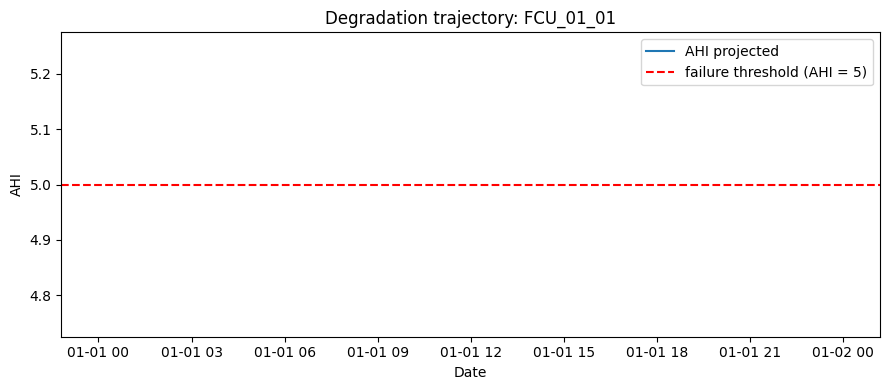

In [15]:
# Pick one FCU and plot its degradation trajectory.
import matplotlib.pyplot as plt

id_col = "Asset_ID" if "Asset_ID" in traj.columns else "asset_id"
fcu_id = "FCU_01_01"
one = traj[traj[id_col] == fcu_id].copy()
one["Date"] = pd.to_datetime(one["Date"])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(one["Date"], one["AHI_Predicted"], label="AHI projected")
ax.axhline(5, color="red", linestyle="--", label="failure threshold (AHI = 5)")
ax.set_title(f"Degradation trajectory: {fcu_id}")
ax.set_xlabel("Date")
ax.set_ylabel("AHI")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Summary of the projection per asset (years left until AHI = 5).
summary = pd.DataFrame(load_json("degradation_summary"))
cols = ["asset_id", "asset_type", "ahi_start", "ahi_end",
        "delta_years", "cibse_life_expectancy"]
summary[cols].head(15)

,asset_id,asset_type,ahi_start,ahi_end,delta_years,cibse_life_expectancy
0,PUMP_DHW_1,Pump,94.2,65.2008,1.53,25.0
1,PUMP_DHW_S,Pump,70.2,4.9949,-6.22,25.0
2,PUMP_LTHW_2,Pump,82.2,4.9960,1.37,25.0
3,AHU_2,AHU,77.3,9.1969,3.58,15.0
4,FCU_03_01,FCU,77.3,9.1969,3.58,15.0
5,FCU_04_01,FCU,77.3,9.1969,3.58,15.0
6,PUMP_DHW_2,Pump,82.2,4.9960,1.37,25.0
7,AHU_1,AHU,65.3,4.9918,-0.83,15.0
8,FCU_06_01,FCU,77.3,9.1969,3.58,15.0
9,FCU_08_01,FCU,77.3,9.1969,3.58,15.0


## 6. S5 — Random Forest per asset type

S5 trains one Random Forest per asset type (FCU, AHU, Pump) on a feature
matrix built from the daily energy, the indoor / outdoor temperature delta,
and a few derived features (cumulative power, climate stress, etc.).

The target is `Daily_Degradation`, a synthetic per-day decrement of AHI
distributed over the asset's available operational data. As discussed in
section 5 above, the model's output is no longer used for the forecast,
but the model is still trained for **trace** purposes and to study which
features drive the predicted rate.

The cell below loads the trained FCU model and shows the most informative
features.

In [17]:
import joblib

model_path = MODELS / "rf_model_FCU.pkl"
model = joblib.load(model_path)
print("Model:", type(model).__name__)
print("Trees:", model.n_estimators)
print("Max depth:", model.max_depth)

Model: RandomForestRegressor
Trees: 200
Max depth: 15


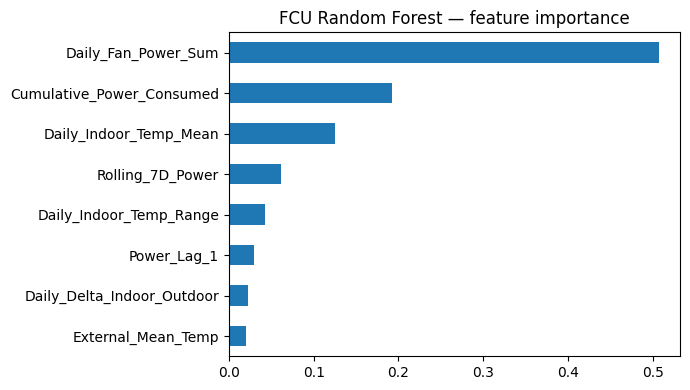

Daily_Fan_Power_Sum           0.506590
Cumulative_Power_Consumed     0.192778
Daily_Indoor_Temp_Mean        0.124727
Rolling_7D_Power              0.060939
Daily_Indoor_Temp_Range       0.042979
Power_Lag_1                   0.029266
Daily_Delta_Indoor_Outdoor    0.022608
External_Mean_Temp            0.020113
dtype: float64

In [18]:
# Feature importances. The names are stored on the model itself.
features = list(model.feature_names_in_)
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind="barh", ax=ax)
ax.set_title("FCU Random Forest — feature importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

importances

In [19]:
# Validation metrics from the registry (latest version per asset type).
registry = pd.DataFrame(load_json("model_registry"))
registry["trained_at"] = pd.to_datetime(
    registry["trained_at"].apply(lambda v: v["$date"] if isinstance(v, dict) else v),
    errors="coerce",
)
latest = registry.sort_values("trained_at").groupby("asset_type").tail(1)
metric_cols = ["asset_type", "version", "n_train_samples", "n_test_samples",
               "mse", "mae", "r2"]
metric_cols = [c for c in metric_cols if c in latest.columns]
latest[metric_cols]

,asset_type,version,n_train_samples,n_test_samples,mse,mae,r2
4,AHU,2,1091,273,0.000300,0.005975,0.849810
5,Pump,2,2727,682,0.000155,0.005487,0.935638
6,FCU,1778580684,1724,432,NaN,1.610370,0.684323


## 7. Where to go next

- The full source for each stage is in `S1_asset_classification.py`,
  `S2_asset_health_index.py`, `S3_baseline_usage.py`, `S4_degradation_rate.py`
  and `S5_ai_training.py` at the root of the repository.
- `cimba_mongo.py` is the persistence layer; in this notebook we read from
  JSON snapshots instead, but the field names match the MongoDB collections.
- `README.md` explains how to run the full pipeline against a local MongoDB,
  if you want to reproduce results from scratch.

Thank you for reviewing.